# Erosion and Dilation

**Learning Objectives:**

Before going through this section, be sure to understand reflection and translation in case of morphological processing. After going through this section, you should be able to:
1. Define Erosion and Dilation, and state their properties and usage
2. Interrelate Erosion and Dilation.
3. Explain the working proces of Dilation and Erosion in binary image


**Detailed outline of the reading material:**

* Erosion
  * Introduction
  * Working process
  * Properties
* Dilation
  * Introduction
  * Working process
  * Properties



**NOTE:**
Erosion and dilation are the dual fundamental operations for morphological processing. The rest of the operations rely on these operations.

## Erosion

### Introduction

Erosion is a morphological operation where you erode the boundary area of foreground pixels(i.e., white or 1's pixels). Now, you know that erosion operation shrinks the areas of the foreground pixels, or you can say that holes within those areas become larger. Using erosion, you can eliminate the narrow regions and make thin the wider ones.


Let's see the mathematical definition of the erosion. For this, let us consider a set $A$ that contains the foreground pixels. If $ B $ is a structuring element, and if there is a pixel $z$, which translates $ B $ into another position such that $ B $ is in $ A $, then the set containing all such $z$ is the eroded representation of $A$. Mathematically we can represent this as:

$$
    A \ominus B = \{ z | (B)_z \subseteq A \}
$$


In the case of image $I$, there are foreground pixels and background pixels(0's or black pixels). Therefore inputs and outputs are images, and you can represent it as:

$$
    I \ominus B = \{ z|(B)_z \subseteq A\ and\ A \subseteq I\} \cup \{ A^c | A^c \subseteq I \}
$$
This means that what we perform erosion on foreground pixels and combine all the background pixels (pixels in $A^c$), results in a complete image.

**NOTE:**

* Erosion removes the pixels on the boundaries
* Structuring element is a matrix of 1's and 0's
* Structuring element is a sub-image
* For a grayscale image,

  Erosion of a grayscale image of function $f$ with grayscale structuring element $b$ at the location (x,y) is the minimum value of the image in the region coincident with $b(x,y)$ when the origin of b is at $(x,y)$ (<a>Gonzalez, R. C., Woods, R. E., & Eddins, S. L., 2004, p.855</a>).  
$$
(f\ominus b)(x,y) = \min_{(s,t)\in b}{f(x+s, y+t)}
$$

### Working Process



For clarification, let's see a simple example to explain it's working process.

You know any morphological operations takes image and structural element as input. So, let's assume the following matrices: $ A $ and $ B $ matrices as image and structural element(origin being at center) to show the working process of erosion.

$$
A = \begin{bmatrix}
1 & 1 & 1 & 1 & 1\\
1 & 1 & 1 & 1 & 1\\
1 & 1 & 1 & 1 & 1\\
1 & 1 & 1 & 1 & 1\\
1 & 1 & 1 & 1 & 1\\
\end{bmatrix}
\quad
B = \begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1 \\
\end{bmatrix}
$$

On applying erosion, you will get the new eroded image matrix, $C$. Mathematically, you can represent the erosion operation as follows:
$$
A\ominus B \rightarrow C \quad \text{where}\ C\text{ is the eroded matrix}
$$

On applying erosion operation, new image matrix $C$ becomes:
$$
C = \begin{bmatrix}
0 & 0 & 0 & 0 & 0\\
0 & 1 & 1 & 1 & 0\\
0 & 1 & 1 & 1 & 0\\
0 & 1 & 1 & 1 & 0\\
0 & 0 & 0 & 0 & 0\\
\end{bmatrix}
$$

Here, the question arises on how you can do this calculation. The erosion operation performed above is straightforward. If you follow the following steps, you will be able to complete the erosion operation:

1. You need to overlap each pixel of the image with the origin of the structuring element and slide it through each pixel.
2. You need to see if the overlapping of the structuring element perfectly matches or not with the area that you overlap it. If it perfectly matches, the pixel value becomes 1 else 0.

Like in the above example, the boundary pixels of the image matrix becomes 0 because when you overlap it with the structuring element, as it does not match perfectly with the structuring element. You will be more clear if you see the picture below.



<figure>
<center>
<!-- <img src ='https://drive.google.com/uc?id=1oEv9Oj7A_4S4pq0s6zsVZzSWkqsinpBJ' alt='IMAGE' /> -->
<img src="https://i.postimg.cc/d0XKdQHD/image.png"/>
<figcaption> Figure 1: Showing one step of above erosion operation
</figcaption>
</center>
</figure>

From the above picture, you know how to overlap the structuring element with the provided image matrix. Here, you see that the structuring does not entirely overlap with the image matrix. So, the first pixel of the matrix becomes zero. Similarly, if you overlap the other pixel value of the image with the structuring element by sliding it through each pixel, you will get the final eroded matrix $ C $.

**NOTE:**

* You need to overlap the origin with pixel values on which you perform the erosion operation, as shown in the figure above.

From the above example, you know how you perform the erosion operation. Now, let's see an implementation of erosion operation using OpenCV tools.

#### Implementation


In [ ]:
!curl -o img.png "https://docs.opencv.org/3.4/Morphology_1_Tutorial_Theory_Original_Image.png"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1126  100  1126    0     0   1653      0 --:--:-- --:--:-- --:--:--  1651


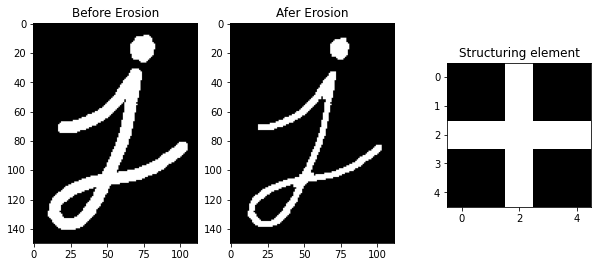

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create a structure element(SE).
erosion_type = cv2.MORPH_CROSS # choosing cross-shape SE
erosion_size = 2
# getStructuringElement takes three arguments (shape of SE, size of SE, anchor position of SE(orgin))
element = cv2.getStructuringElement(erosion_type, (2 * erosion_size + 1, 2 * erosion_size+1), (erosion_size , erosion_size))
img = cv2.imread("img.png")
# erode takes two arguments here,(image, SE)
eroded = cv2.erode(img, element)
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(img)
ax1.set_title("Before Erosion")
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(eroded)
ax2.set_title("After Erosion")
ax3 = fig.add_axes([.7, .4, .2, .2])
ax3.set_title("Structuring element")
ax3.imshow(element, cmap='gray')

Here, you see that after applying the erosion operation, the thickness of the character reduces. That is, the character has been more thinner than the original one. This is because the erosion operation has eroded the boundaries of regions of foreground pixels(white pixels). For detailed understanding of the functions like `getStructuringElement`, `erode`, you can follow the following links: [getStructuringElement](https://docs.opencv.org/4.4.0/d4/d86/group__imgproc__filter.html#gac342a1bb6eabf6f55c803b09268e36dc), [cv2.erode](https://docs.opencv.org/4.4.0/d4/d86/group__imgproc__filter.html#gaeb1e0c1033e3f6b891a25d0511362aeb).


### Properties

* Translation invariant

  $$
  (A + x)\ominus B = (A \ominus B) +x = A\ominus (B+x)
  $$

  Shifting in the image object or structuring element does not affect the erosion operation.

* Erosion is increasing

  $$If A \subseteq C, A\ominus B \subseteq C \ominus B$$
  where $B$ is structuring element and $A$ and $C$ are image objects.

*  Satisfy Decomposition theorem
$$
  A \ominus(B\cup C) = (A \ominus B)\cup(A\ominus C)
$$

* Erosion also statisfies following condition:
$$(A \ominus B)\oplus C = A\ominus(B\oplus C)$$
where $\oplus$ represent dilation

## Dilation

### Introduction

Dilation is just the opposite process of erosion operation. If erosion decreases the size of the image, dilation increases the image size. It only enlarges the boundary regions of the foreground pixels. One of its uses is to bridge the gap in a picture as it is an expansion operator that enlarges the image.

Like in erosion, let's define it mathematically. If $ A $ is the set representing foreground pixels, and $ B $ is the structuring elements, we can represent dilation of $ A $ by $ B $ $(A \oplus B)$ as
$$
    A \oplus B = \{z|(\hat{B})_z \cap A \ne \phi \}
$$

This means if you reflect the element about its origin, and translate this reflection by pixel z, the set of all z consists of pixels where foreground elements of structure $B$ overlap with at least one element of $A$.

If you see the structuring element as some kernel, this process is similar to convolution, where you flip the kernel and slide through the image. In this case, we only take those pixels where this kernel and foreground pixels overlap.

**NOTE:**

* For a grayscale image,

  Dilation of a grayscale image $f$ with grayscale structuring element $b$ at any location (x,y) is the maximum value of the image in the window spanned by $\hat{b}$ when the origin of $\hat{b}$ is at (x,y)(<a>Gonzalez, R. C., Woods, R. E., & Eddins, S. L., 2004, p.855</a>).
$$
(f\oplus b)(x) = \max_{(s,t)\in \hat{b}}{f(x-s, y-s)},
$$
where, $\hat{b}(x,y) = b(-x, -y)$, i.e., structuring element b is reflected about its origin


### Working Process



Similar to erosion, for explaining the working process of dilation in a binary image, we take arbitrary matrices $A$ and $B$ as image objects and structuring elements, respectively, as shown below and perform the dilation operation.

$$
A = \begin{bmatrix}
0 & 0 & 0 & 0 & 0\\
0 & 1 & 0 & 1 & 0\\
0 & 1 & 1 & 0 & 0\\
0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 0\\
\end{bmatrix}
\quad
B = \begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1 \\
\end{bmatrix}
$$

On applying dilation, you will get the new eroded image matrix, $C$. Mathematically, you can represent the erosion operation as follows:
$$
A\oplus B \rightarrow C \quad \text{where}\ C\text{ is the dilated matrix}
$$

On applying erosion operation, new image matrix $C$ becomes:
$$
C = \begin{bmatrix}
1 & 1 & 1 & 1 & 1\\
1 & 1 & 1 & 1 & 1\\
1 & 1 & 1 & 1 & 1\\
1 & 1 & 1 & 1 & 0\\
1 & 1 & 1 & 0 & 0\\
\end{bmatrix}
$$

The working process is similar to erosion. Here, you slide the structuring element over the image objects from left to right such that every pixel in the image objects in covered. The difference from erosion is that if you find any element of the structuring element overlaps(perfectly matches) with the image pixels, the image pixels overlapping with the origin of the structuring element becomes 1 else 0.

Let's see its simple implementation
using OpenCV. Unlike erosion, we are only interested in dilation when there is at least one foreground element touching the structuring element. If we mark these locations where this process occurs, we get the image as soon in the figure below.

## Implementation


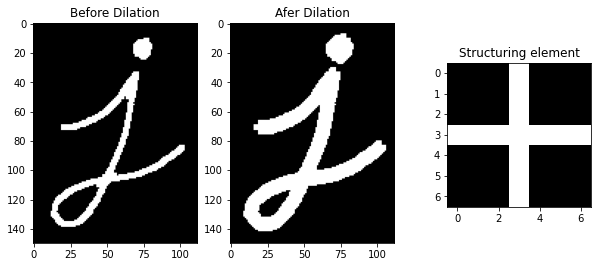

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create a structure element.
dilation_type = cv2.MORPH_CROSS ## choosing cross-shape SE
dilation_size = 3
element = cv2.getStructuringElement(dilation_type, (2 * dilation_size + 1, 2 * dilation_size+1), (dilation_size , dilation_size))
# Here, dialting the eroded image
#dialted takes two arguments here, (image, SE)
dilated = cv2.dilate(eroded, element)
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(eroded)
ax1.set_title("Before Dilation")
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(dilated)
ax2.set_title("After Dilation")
ax3 = fig.add_axes([.7, .4, .2, .2])
ax3.set_title("Structuring element")
ax3.imshow(element, cmap='gray')

In case you are still confused with that dilation is doing, notice the cross in the tip on j. This shape arises because of our structuring element. For detailed understanding of the function `dilate`, you can follow the following link: [cv2.dilate](https://docs.opencv.org/4.4.0/d4/d86/group__imgproc__filter.html#ga4ff0f3318642c4f469d0e11f242f3b6c).

### Properties

* Translation invariant

  $$
 (A \oplus B) +x = A\oplus (B+x)
  $$

  Shifting in the image object or structuring element does not affect the dilation operation.

* Dilation is increasing

  $$If A \subseteq C, A\oplus B \subseteq C \oplus B$$
  where $B$ is structuring element and $A$ and $C$ are image objects.

*  Satisfy Decomposition theorem
$$
  A \ominus(B\cup C) = (A \ominus B)\cup(A\ominus C)
$$

* Satisfy associative property

 $$
 (A \oplus B)\oplus C = A\oplus (B\oplus C)
  $$

* Satisfy commutative property
 $$
 A \oplus B  = B\oplus A
  $$




**Duality**

By using some complements and reflection, we can get the dual relationship between erosion and dilation.

$$
    (A \oplus B)^c = A^c \ominus \hat{B}
$$
$$
    (A \ominus B) ^ c = A^c \oplus \hat{B}
$$
where $\hat{B}$ is the reflection of B.

From the above equations, it is clear that you obtain the results similar to the diation of the $A$ by performing the erosion on background pixels of $A$(i.e $A^{c}$) and taking its complement and vice-versa. Here, the structuring element on both cases are $B$, and $\hat{B}$. If the structuring element is symmetric, in the above equations, $B = \hat{B}$.  

# Key Takeaways

1. Erosion shrinks or thins the foreground elements in a binary image.
2. Dilation grows or thickens the foreground elements in a binary image.
3. Erosion and Dilation are dual of each other.